# Heart Segmentation — Single Fold, Single GPU, 90+ Dice Target

Clean setup: UNet + ResNet18, PyTorch backend, aggressive augmentation.

In [1]:
!pip install git+https://github.com/innat/medic-ai.git -q
!pip install scikit-learn nibabel -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import json
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

import keras
import torch

from medicai.models import UNet
from medicai.losses import BinaryDiceCELoss
from medicai.metrics import BinaryDiceMetric
from medicai.transforms import (
    Compose,
    ScaleIntensityRange,
    CropForeground,
    RandCropByPosNegLabel,
    RandFlip,
    RandRotate90,
    RandShiftIntensity,
)

print(f"Backend : {keras.config.backend()}")
print(f"Keras   : {keras.version()}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

2026-03-22 10:06:39.664607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774173999.687344     269 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774173999.694966     269 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774173999.714734     269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774173999.714756     269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774173999.714759     269 computation_placer.cc:177] computation placer alr

Backend : torch
Keras   : 3.10.0
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [3]:
CT_DIR  = Path("/kaggle/input/datasets/arjunashokbhandary/gsoc-coca-segment/data_totalseg/inputs")
GT_DIR  = Path("/kaggle/input/datasets/arjunashokbhandary/coca-gt/kaggle/working/gsoc-coca-gt")
OUT_DIR = Path("/kaggle/working/heart_seg_output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CROP_SHAPE    = (128, 128, 128)
HU_MIN        = -175
HU_MAX        = 400
BATCH_SIZE    = 2
NUM_SAMPLES   = 1
EPOCHS        = 200
WARMUP_EPOCHS = 10
LEARNING_RATE = 3e-4
MIN_LR        = 1e-6
WEIGHT_DECAY  = 5e-4
VAL_SPLIT     = 0.15
SEED          = 50

In [4]:
def discover_pairs(ct_dir, gt_dir):
    pairs = []
    for ct_path in sorted(list(ct_dir.glob("*_img.nii.gz")) + list(ct_dir.glob("*_img.nii"))):
        scan_id = ct_path.name.replace("_img.nii.gz", "").replace("_img.nii", "")
        for ext in (".nii.gz", ".nii"):
            gt_path = gt_dir / scan_id / f"{scan_id}_binary{ext}"
            if gt_path.exists():
                pairs.append({"scan_id": scan_id, "image": str(ct_path), "label": str(gt_path)})
                break
    return pairs

pairs = discover_pairs(CT_DIR, GT_DIR)
print(f"Found {len(pairs)} pairs")

train_pairs, val_pairs = train_test_split(pairs, test_size=VAL_SPLIT, random_state=SEED)
print(f"Train={len(train_pairs)}  Val={len(val_pairs)}")

Found 47 pairs
Train=39  Val=8


In [5]:
def load_pair(image_path, label_path):
    image_nii = nib.load(image_path)
    label_nii = nib.load(label_path)
    image  = image_nii.get_fdata().astype(np.float32)
    label  = label_nii.get_fdata().astype(np.float32)
    affine = np.array(image_nii.affine, dtype=np.float32)
    image  = np.transpose(image, (2, 1, 0))
    label  = np.transpose(label, (2, 1, 0))
    affine[:, :3] = affine[:, [2, 1, 0]]
    label = (label > 0.5).astype(np.float32)
    image = image[..., np.newaxis]
    label = label[..., np.newaxis]
    return {"image": image, "label": label}, {"affine": affine}

_d, _ = load_pair(pairs[0]["image"], pairs[0]["label"])
print(f"image: {_d['image'].shape}   label: {_d['label'].shape}")
print(f"Label fraction: {_d['label'].mean():.4f}")

image: (219, 309, 309, 1)   label: (219, 309, 309, 1)
Label fraction: 0.1100


In [6]:
train_transform = Compose([
    ScaleIntensityRange(
        keys=["image"], a_min=HU_MIN, a_max=HU_MAX,
        b_min=0.0, b_max=1.0, clip=True,
    ),
    CropForeground(keys=("image", "label"), source_key="image"),
    RandCropByPosNegLabel(
        keys=["image", "label"], spatial_size=CROP_SHAPE,
        pos=2, neg=1, num_samples=NUM_SAMPLES,
        image_reference_key="image", image_threshold=0,
    ),
    RandFlip(keys=["image", "label"], spatial_axis=[0], prob=0.5),
    RandFlip(keys=["image", "label"], spatial_axis=[1], prob=0.5),
    RandFlip(keys=["image", "label"], spatial_axis=[2], prob=0.5),
    RandRotate90(keys=["image", "label"], prob=0.5, max_k=3, spatial_axes=(0, 1)),
    RandRotate90(keys=["image", "label"], prob=0.5, max_k=3, spatial_axes=(1, 2)),
    RandShiftIntensity(keys=["image"], offsets=0.2, prob=0.8),
])

val_transform = Compose([
    ScaleIntensityRange(
        keys=["image"], a_min=HU_MIN, a_max=HU_MAX,
        b_min=0.0, b_max=1.0, clip=True,
    ),
    CropForeground(keys=("image", "label"), source_key="image"),
    RandCropByPosNegLabel(
        keys=["image", "label"], spatial_size=CROP_SHAPE,
        pos=1, neg=0, num_samples=1,
        image_reference_key="image", image_threshold=0,
    ),
])

print("Transforms ready")

Transforms ready


In [7]:
class HeartSegDataset(keras.utils.PyDataset):
    def __init__(self, pairs, transform, batch_size, num_samples=1, shuffle=False, **kw):
        super().__init__(**kw)
        self.pairs      = pairs
        self.transform  = transform
        self.batch_size = batch_size
        self.num_samples = num_samples
        self.shuffle    = shuffle
        self._build_index()

    def _build_index(self):
        self._index = [(vi, ci) for vi in range(len(self.pairs))
                                for ci in range(self.num_samples)]
        if self.shuffle:
            np.random.shuffle(self._index)

    def __len__(self):
        return math.ceil(len(self._index) / self.batch_size)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self._index)

    def __getitem__(self, idx):
        batch = self._index[idx * self.batch_size : (idx + 1) * self.batch_size]
        images, labels = [], []
        for vi, ci in batch:
            p = self.pairs[vi]
            data, meta = load_pair(p["image"], p["label"])
            out = self.transform(data, meta)
            img, lbl = out["image"], out["label"]
            if isinstance(img, list):
                ci = min(ci, len(img) - 1)
                img, lbl = img[ci], lbl[ci]
            if hasattr(img, "numpy"): img = img.numpy()
            if hasattr(lbl, "numpy"): lbl = lbl.numpy()
            images.append(img)
            labels.append(lbl)
        return np.stack(images), np.stack(labels)


train_ds = HeartSegDataset(
    train_pairs, train_transform,
    batch_size=BATCH_SIZE, num_samples=NUM_SAMPLES, shuffle=True,
)
val_ds = HeartSegDataset(
    val_pairs, val_transform,
    batch_size=1, num_samples=1, shuffle=False,
)

_x, _y = train_ds[0]
print(f"Batch: {_x.shape}  [{_x.min():.2f}, {_x.max():.2f}]")
print(f"Label: {_y.shape}  heart voxels={int(_y.sum())}")
print(f"Steps/epoch: {len(train_ds)} train, {len(val_ds)} val")

I0000 00:00:1774174004.428644     269 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


Batch: (2, 128, 128, 128, 1)  [-0.05, 1.00]
Label: (2, 128, 128, 128, 1)  heart voxels=2021751
Steps/epoch: 20 train, 8 val


In [8]:
model = UNet(
    input_shape=(*CROP_SHAPE, 1),
    num_classes=1,
    encoder_name='resnet18',
    classifier_activation=None,
)

print(f"Parameters: {model.count_params():,}")
model.summary(line_length=100)

Parameters: 42,622,289


Model: "UNet3D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 128, 128, 128,   │              0 │ -                       │
│                             │ 1)                      │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1_pad (ZeroPadding3D)   │ (None, 134, 134, 134,   │              0 │ input_layer[0][0]       │
│                             │ 1)                      │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1_conv (Conv3D)         │ (None, 64, 64, 64, 64)  │         21,952 │ conv1_pad[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1_bn                    │ (None, 64, 64, 64, 64)  │            256 │ conv1_conv[0][0]        │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1_relu (Activation)     │ (None, 64, 64, 64, 64)  │              0 │ conv1_bn[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ pool1_pad (ZeroPadding3D)   │ (None, 66, 66, 66, 64)  │              0 │ conv1_relu[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ pool1_pool (MaxPooling3D)   │ (None, 32, 32, 32, 64)  │              0 │ pool1_pad[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stack0_block0_1_conv        │ (None, 32, 32, 32, 64)  │        110,592 │ pool1_pool[0][0]        │
│ (Conv3D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stack0_block0_1_bn          │ (None, 32, 32, 32, 64)  │            256 │ stack0_block0_1_conv[0… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stack0_block0_1_relu        │ (None, 32, 32, 32, 64)  │              0 │ stack0_block0_1_bn[0][… │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stack0_block0_2_conv        │ (None, 32, 32, 32, 64)  │        110,592 │ stack0_block0_1_relu[0… │
│ (Conv3D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stack0_block0_2_bn          │ (None, 32, 32, 32, 64)  │            256 │ stack0_block0_2_conv[0… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stack0_block0_add (Add)     │ (None, 32, 32, 32, 64)  │              0 │ pool1_pool[0][0],       │
│                             │                         │                │ stack0_block0_2_bn[0][… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stack0_block0_out           │ (None, 32, 32, 32, 64)  │              0 │ stack0_block0_add[0][0] │
│ (Activation)                │                         │    

 Total params: 42,622,289 (162.59 MB)

 Trainable params: 42,610,705 (162.55 MB)

 Non-trainable params: 11,584 (45.25 KB)

In [9]:
def warmup_cosine_lr(epoch, current_lr):
    if epoch < WARMUP_EPOCHS:
        return MIN_LR + (LEARNING_RATE - MIN_LR) * (epoch / WARMUP_EPOCHS)
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return MIN_LR + 0.5 * (LEARNING_RATE - MIN_LR) * (1 + math.cos(math.pi * progress))

for e in [0, 10, 50, 100, 199]:
    print(f"Epoch {e:>3d}  LR = {warmup_cosine_lr(e, None):.2e}")

Epoch   0  LR = 1.00e-06
Epoch  10  LR = 3.00e-04
Epoch  50  LR = 2.68e-04
Epoch 100  LR = 1.63e-04
Epoch 199  LR = 1.02e-06


In [10]:
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=MIN_LR,
        weight_decay=WEIGHT_DECAY,
    ),
    loss=BinaryDiceCELoss(from_logits=True, num_classes=1),
    metrics=[BinaryDiceMetric(from_logits=True, num_classes=1)],
)

callbacks = [
    keras.callbacks.LearningRateScheduler(warmup_cosine_lr, verbose=0),
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUT_DIR / "best_model.keras"),
        monitor="val_binary_dice_metric", mode="max",
        save_best_only=True, verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_binary_dice_metric", mode="max",
        patience=50, restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.CSVLogger(str(OUT_DIR / "training_log.csv")),
]

print("Compiled")

Compiled


In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nBest val Dice: {max(history.history.get('val_binary_dice_metric', [0])):.4f}")

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - binary_dice_score: 0.5680 - loss: 1.1894 - val_binary_dice_score: 0.4013 - val_loss: 1.2371 - learning_rate: 1.0000e-06
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - binary_dice_score: 0.6159 - loss: 1.1228 - val_binary_dice_score: 0.6932 - val_loss: 1.1471 - learning_rate: 3.0900e-05
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - binary_dice_score: 0.7218 - loss: 1.0349 - val_binary_dice_score: 0.7295 - val_loss: 1.0298 - learning_rate: 6.0800e-05
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - binary_dice_score: 0.7584 - loss: 0.8281 - val_binary_dice_score: 0.8099 - val_loss: 0.8658 - learning_rate: 9.0700e-05
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - binary_dice_score: 0.7168 - loss: 0.8997 - val_binary_dice_score: 0.4875 - val_loss: 1.0383 - learning_rate: 1.2060e-04
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - binary_dice_score: 0.7894 - loss: 0.7298 - val_binary_dice_score: 0.0109 - val_los

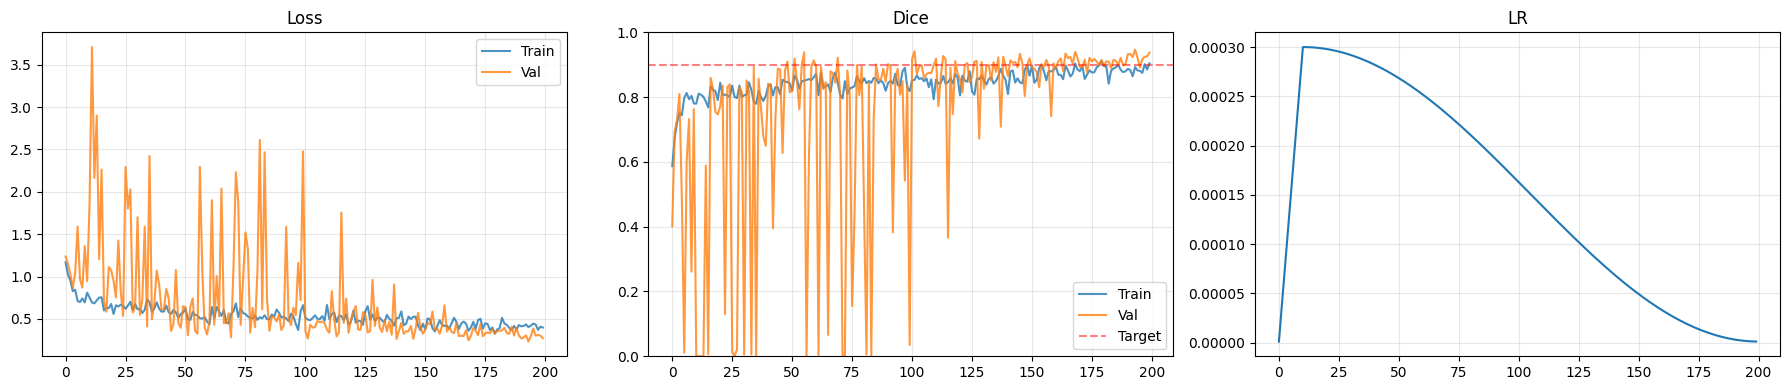

Train Dice: 0.9043  Val Dice: 0.9370  Gap: -0.0327


In [12]:
metric_key = [k for k in history.history.keys() if "dice" in k and "val" not in k][0]
val_metric_key = [k for k in history.history.keys() if "dice" in k and "val" in k][0]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history["loss"],     label="Train", alpha=0.8)
axes[0].plot(history.history["val_loss"], label="Val", alpha=0.8)
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history[metric_key],     label="Train", alpha=0.8)
axes[1].plot(history.history[val_metric_key], label="Val", alpha=0.8)
axes[1].axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='Target')
axes[1].set_title("Dice"); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(alpha=0.3)

n = len(history.history["loss"])
axes[2].plot([warmup_cosine_lr(e, None) for e in range(n)])
axes[2].set_title("LR"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUT_DIR / "training_curves.png"), dpi=150)
plt.show()

final_train = history.history[metric_key][-1]
final_val   = history.history[val_metric_key][-1]
print(f"Train Dice: {final_train:.4f}  Val Dice: {final_val:.4f}  Gap: {final_train - final_val:.4f}")

In [13]:
from medicai.utils.inference import SlidingWindowInference

def predict_volume(model, image_path, label_path):
    data, meta = load_pair(image_path, label_path)
    pre = Compose([
        ScaleIntensityRange(
            keys=["image"], a_min=HU_MIN, a_max=HU_MAX,
            b_min=0.0, b_max=1.0, clip=True,
        ),
        CropForeground(keys=("image", "label"), source_key="image"),
    ])
    out = pre(data, meta)
    ct = out["image"]
    gt = out["label"]
    if hasattr(ct, "numpy"): ct = ct.numpy()
    if hasattr(gt, "numpy"): gt = gt.numpy()

    swi = SlidingWindowInference(
        model=model, num_classes=1, roi_size=CROP_SHAPE,
        sw_batch_size=2, overlap=0.5, mode='gaussian',
    )
    pred     = np.array(swi(ct[np.newaxis]))[0]
    pred_bin = (1.0 / (1.0 + np.exp(-pred)) > 0.5).astype(np.float32)
    inter    = (pred_bin * gt).sum()
    dice     = float(2.0 * inter / (pred_bin.sum() + gt.sum() + 1e-6))
    return ct, gt, pred_bin, dice

In [ ]:
best_model = keras.models.load_model(
    str(OUT_DIR / "best_model.keras"),
    custom_objects={
        "BinaryDiceCELoss": BinaryDiceCELoss,
        "BinaryDiceMetric": BinaryDiceMetric,
    },
    compile=False,
)
best_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=MIN_LR, weight_decay=WEIGHT_DECAY),
    loss=BinaryDiceCELoss(from_logits=True, num_classes=1),
    metrics=[BinaryDiceMetric(from_logits=True, num_classes=1)],
)

results = []
for p in val_pairs:
    _, _, _, dice = predict_volume(best_model, p["image"], p["label"])
    results.append({"scan_id": p["scan_id"], "dice": dice})
    print(f"  {p['scan_id']}  Dice={dice:.4f}")

dices = [r["dice"] for r in results]
print(f"\nMean={np.mean(dices):.4f}  Std={np.std(dices):.4f}  Min={np.min(dices):.4f}  Max={np.max(dices):.4f}")

Total patch 48: 100%|██████████| 24/24 [00:09<00:00,  2.59it/s]


  be9fa3df918a  Dice=0.8995


Total patch 48: 100%|██████████| 24/24 [00:09<00:00,  2.61it/s]


  092c97ecec4b  Dice=0.8225


Total patch 75: 100%|██████████| 38/38 [00:14<00:00,  2.62it/s]


...

  4d9723eef946  Dice=0.8672


Total patch 75: 100%|██████████| 38/38 [00:13<00:00,  2.74it/s]


  43ca4b1f6495  Dice=0.8568


Total patch 32: 100%|██████████| 16/16 [00:05<00:00,  2.69it/s]

  8781c0349102  Dice=0.7270

Mean=0.8583  Std=0.0569  Min=0.7270  Max=0.9213


Total patch 27: 100%|██████████| 14/14 [00:05<00:00,  2.70it/s]


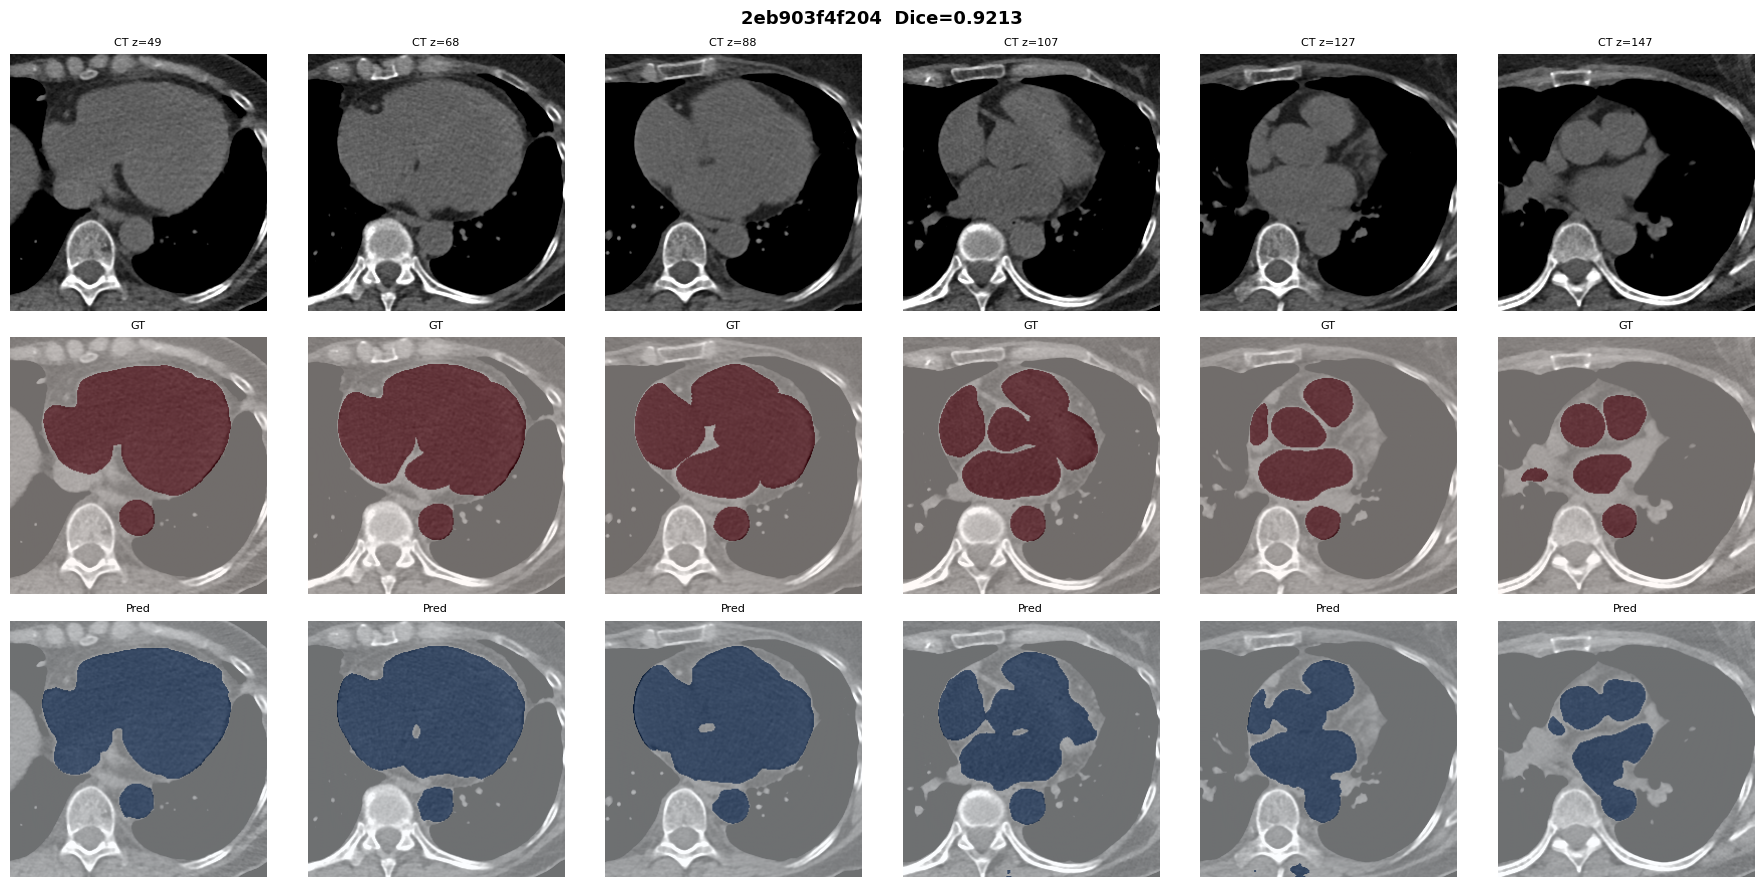

Total patch 32: 100%|██████████| 16/16 [00:06<00:00,  2.67it/s]


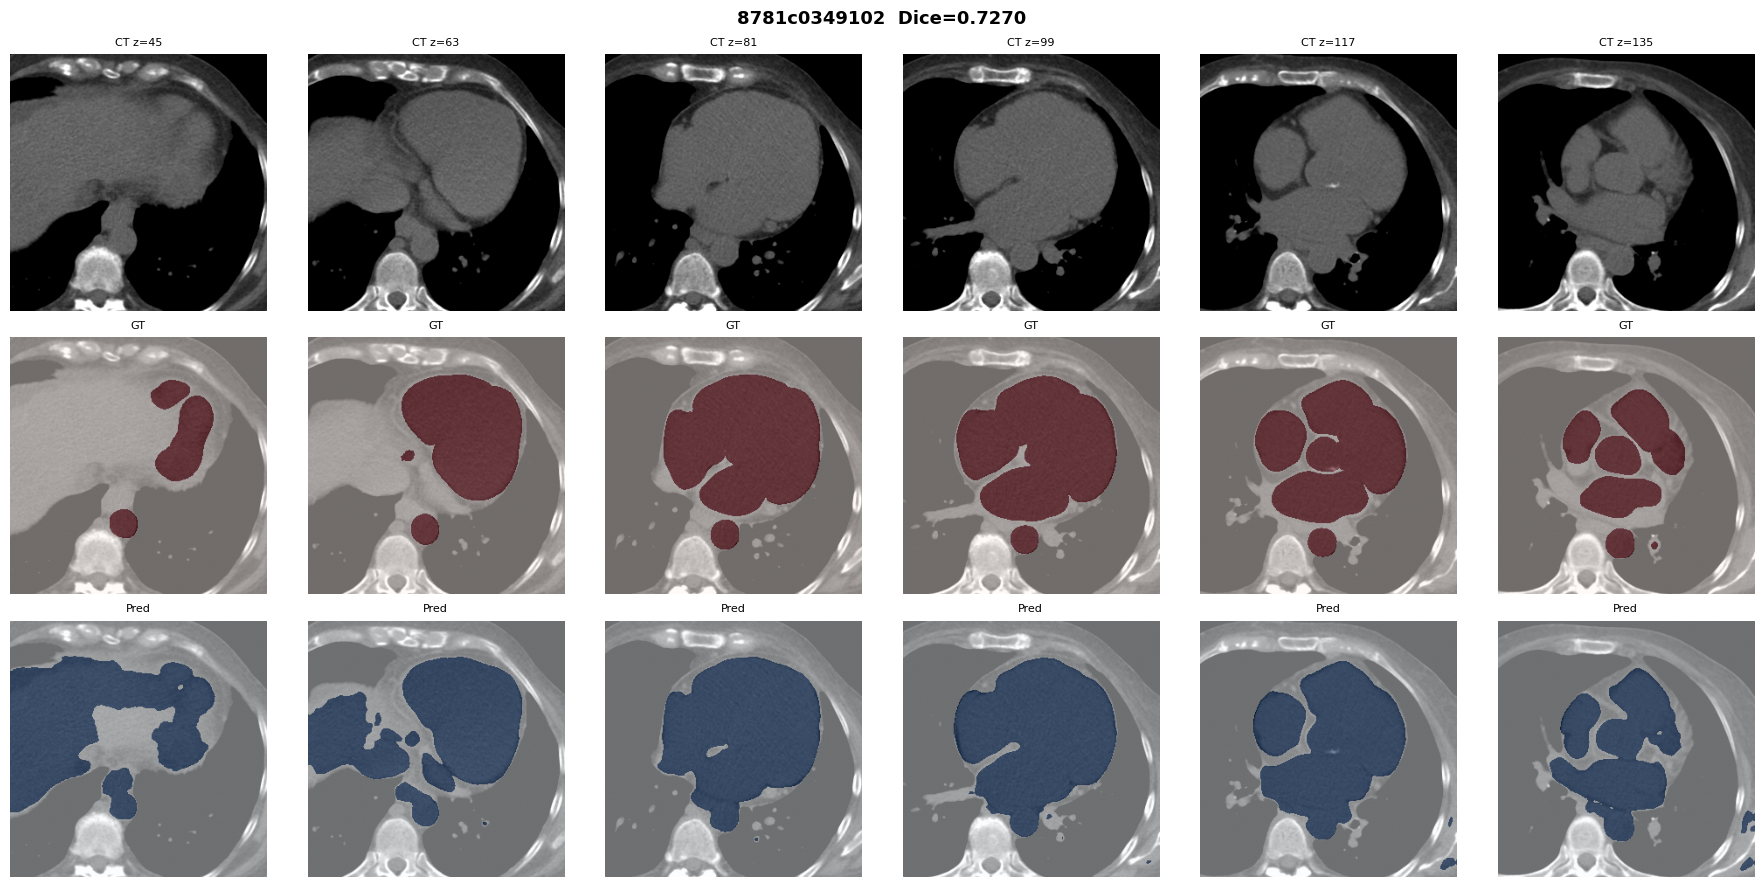

In [ ]:
def visualise(ct, gt, pred, scan_id, dice, n_slices=6):
    D = ct.shape[0]
    idxs = np.linspace(D // 4, 3 * D // 4, n_slices, dtype=int)
    fig, axes = plt.subplots(3, n_slices, figsize=(3 * n_slices, 9))
    fig.suptitle(f"{scan_id}  Dice={dice:.4f}", fontsize=13, fontweight="bold")
    for col, idx in enumerate(idxs):
        s, g, p = ct[idx,:,:,0], gt[idx,:,:,0], pred[idx,:,:,0]
        axes[0,col].imshow(s, cmap="gray", vmin=0, vmax=1)
        axes[0,col].set_title(f"CT z={idx}", fontsize=8); axes[0,col].axis("off")
        axes[1,col].imshow(s, cmap="gray", vmin=0, vmax=1)
        axes[1,col].imshow(g, cmap="Reds",  alpha=0.45)
        axes[1,col].set_title("GT", fontsize=8); axes[1,col].axis("off")
        axes[2,col].imshow(s, cmap="gray", vmin=0, vmax=1)
        axes[2,col].imshow(p, cmap="Blues", alpha=0.45)
        axes[2,col].set_title("Pred", fontsize=8); axes[2,col].axis("off")
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / f"{scan_id}_pred.png"), dpi=150, bbox_inches="tight")
    plt.show()

for res in [max(results, key=lambda r: r["dice"]), min(results, key=lambda r: r["dice"])]:
    p = next(x for x in val_pairs if x["scan_id"] == res["scan_id"])
    ct, gt, pred, dice = predict_volume(best_model, p["image"], p["label"])
    visualise(ct, gt, pred, res["scan_id"], dice)

In [ ]:
stats = {
    "model":         "UNet_resnet18",
    "backend":       keras.config.backend(),
    "mean_dice":     round(float(np.mean(dices)), 4),
    "std_dice":      round(float(np.std(dices)),  4),
    "n_train":       len(train_pairs),
    "n_val":         len(val_pairs),
    "crop_shape":    list(CROP_SHAPE),
    "hu_window":     [HU_MIN, HU_MAX],
    "epochs_trained": len(history.history["loss"]),
    "best_val_dice": round(float(max(history.history.get("val_binary_dice_metric", [0]))), 4),
    "total_params":  model.count_params(),
    "weight_decay":  WEIGHT_DECAY,
    "num_samples":   NUM_SAMPLES,
    "per_scan":      results,
}
with open(OUT_DIR / "eval_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print(json.dumps({k: v for k, v in stats.items() if k != "per_scan"}, indent=2))

{
  "model": "UNet_resnet18",
  "backend": "torch",
  "mean_dice": 0.8583,
  "std_dice": 0.0569,
  "n_train": 39,
  "n_val": 8,
  "crop_shape": [
    128,
    128,
    128
  ],
  "hu_window": [
    -175,
    400
  ],
  "epochs_trained": 200,
  "best_val_dice": 0.0,
  "total_params": 42622289,
  "weight_decay": 0.0005,
  "num_samples": 1
}
